# 02 — Pré-processamento e Feature Engineering (Tabular)

In [1]:
import sys
import os

# Localiza src/ de forma robusta independente de onde o Jupyter foi iniciado.
# Procura subindo a árvore de diretórios a partir do CWD até encontrar src/.
def _find_src_dir():
    current = os.path.abspath(os.getcwd())
    for _ in range(5):  # sobe no máximo 5 níveis
        candidate = os.path.join(current, 'src')
        if os.path.isdir(candidate):
            return candidate
        current = os.path.dirname(current)
    raise RuntimeError(
        f"Diretório src/ não encontrado. CWD: {os.getcwd()}\n"
        "Execute o Jupyter a partir de galaxy_classification/ ou de notebooks/."
    )

src_path = _find_src_dir()
if src_path not in sys.path:
    sys.path.insert(0, src_path)
print(f"src/ no path: {src_path}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

from preprocessing import (
    TABULAR_FEATURES,
    engineer_tabular_features,
    preprocess_tabular_data,
    save_preprocessed_tabular,
    load_preprocessed_tabular,
)

# Reprodutibilidade
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Estilo dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Caminhos — também robustos ao CWD
_project_root = os.path.dirname(src_path)
PROCESSED_DIR = os.path.join(_project_root, 'data', 'processed')
REPORTS_DIR   = os.path.join(_project_root, 'reports', 'figures')
os.makedirs(REPORTS_DIR, exist_ok=True)

print(f"PROCESSED_DIR : {PROCESSED_DIR}")
print(f"REPORTS_DIR   : {REPORTS_DIR}")
print(f"Features tabulares ({len(TABULAR_FEATURES)}): {TABULAR_FEATURES}")

src/ no path: /home/luciano/Documentos/GalaxyNet/galaxy_classification/src
PROCESSED_DIR : /home/luciano/Documentos/GalaxyNet/galaxy_classification/data/processed
REPORTS_DIR   : /home/luciano/Documentos/GalaxyNet/galaxy_classification/reports/figures
Features tabulares (15): ['u', 'g', 'r', 'i', 'z', 'u_g', 'g_r', 'r_i', 'i_z', 'redshift', 'velDisp', 'concentration', 'deVAB_r', 'expAB_r', 'fracDeV_r']


---
## 1. Carregando o Catálogo Mesclado

In [2]:
df = pd.read_csv(os.path.join(PROCESSED_DIR, 'merged_catalog.csv'))

# Corrigir valores com ponto decimal ausente (ex.: 16106 → 16.106)
from preprocessing import fix_missing_decimal
df = fix_missing_decimal(df)

print(f'Shape: {df.shape}')
print(f'\nColunas: {list(df.columns)}')
print(f'\nDistribuição de classes:')
print(df['morph_class'].value_counts())
df.head(3)

fix_missing_decimal: 0 valor(es) corrigido(s)
Shape: (9054, 33)

Colunas: ['objid', 'ra', 'dec', 'u', 'g', 'r', 'i', 'z', 'petroRad_r', 'petroR50_r', 'petroR90_r', 'deVAB_r', 'expAB_r', 'lnLDeV_r', 'lnLExp_r', 'lnLStar_r', 'fracDeV_r', 'redshift', 'zErr', 'velDisp', 'velDispErr', 'gz2_objid', 'gz2_ra', 'gz2_dec', 'total_votes_gz2', 't01_smooth_or_features_a01_smooth_fraction', 't01_smooth_or_features_a02_features_or_disk_fraction', 't01_smooth_or_features_a03_star_or_artifact_fraction', 't03_bar_a06_bar_fraction', 't03_bar_a07_no_bar_fraction', 't04_spiral_a08_spiral_fraction', 't04_spiral_a09_no_spiral_fraction', 'morph_class']

Distribuição de classes:
morph_class
Elliptical    7595
Spiral        1198
Irregular      261
Name: count, dtype: int64


,objid,ra,dec,u,g,r,i,z,petroRad_r,petroR50_r,...,gz2_dec,total_votes_gz2,t01_smooth_or_features_a01_smooth_fraction,t01_smooth_or_features_a02_features_or_disk_fraction,t01_smooth_or_features_a03_star_or_artifact_fraction,t03_bar_a06_bar_fraction,t03_bar_a07_no_bar_fraction,t04_spiral_a08_spiral_fraction,t04_spiral_a09_no_spiral_fraction,morph_class
0,1237648702972493979,197.154923,-1.252763,19.52571,17.74521,16.76546,16.32036,15.99769,5.207552,2.328935,...,-1.252742,141,0.822,0.111,0.067,0.0,1.0,0.5,0.5,Elliptical
1,1237648702972952662,198.136504,-1.241744,19.71973,17.73679,16.75908,16.32437,15.96696,3.630058,1.590797,...,-1.241711,143,0.891,0.043,0.065,0.5,0.5,0.0,1.0,Elliptical
2,1237648702973804683,200.166657,-1.101729,19.85966,17.89301,16.95394,16.55142,16.21367,3.651988,1.669565,...,-1.101735,158,0.826,0.109,0.065,0.2,0.8,0.0,1.0,Elliptical


---
## 1.1. Remoção de Linhas com Precisão Não-Padronizada

Algumas linhas do catálogo contêm valores com número de casas decimais
significativamente inferior ao padrão do SDSS DR17 para aquela grandeza
(ex.: `petroR50_r = 1.988` em vez de `1.988xxx`, exibido como `1988` em
editores com locale brasileiro). Isso indica dados truncados, arredondados
ou provenientes de formato inconsistente.

**Critério:** para cada coluna de medição física do SDSS, calcula-se a moda
do número de casas decimais ao longo de todo o catálogo. Linhas onde qualquer
coluna apresenta menos de `moda − 2` casas decimais são descartadas.

In [3]:
import statistics as _stats

# Colunas fotométricas onde a presença do ponto decimal é obrigatória.
# Excluídas intencionalmente: lnLDeV_r, lnLExp_r, lnLStar_r (log-verossimilhanças que
# o SDSS armazena como inteiros quando muito negativas), fracDeV_r (valores arredondados
# esperados), velDisp/velDispErr (0.0 é sentinela válida do SDSS para 'não medido').
_PHOTO_COLS = [
    'u', 'g', 'r', 'i', 'z',
    'petroRad_r', 'petroR50_r', 'petroR90_r',
    'deVAB_r', 'expAB_r',
    'redshift', 'zErr',
    'velDispErr',
]

def _n_dec_str(val):
    """Conta casas decimais usando o string original do CSV (preserva zeros finais)."""
    val = str(val).strip()
    if 'e' in val.lower():
        base = val.lower().split('e')[0]
        return len(base.split('.')[1]) if '.' in base else 0
    return len(val.split('.')[1]) if '.' in val else 0

# Ler o CSV como strings para preservar a representação original dos valores
_df_str = pd.read_csv(
    os.path.join(PROCESSED_DIR, 'merged_catalog.csv'), dtype=str
)

# ── Corrigir valores com ponto decimal ausente ───────────────────────────
# Heurística: valor sem ponto decimal cuja divisão por 1000 cai dentro da
# faixa física esperada da coluna → ponto decimal foi perdido (artefato de
# locale ou exportação CSV).  Ex.: 16106 → 16.106  |  230421 → 230.421
_RANGE_MAP = {
    'u': (10.0, 25.0), 'g': (10.0, 25.0), 'r': (10.0, 25.0),
    'i': (10.0, 25.0), 'z': (10.0, 25.0),
    'petroRad_r': (0.1, 200.0), 'petroR50_r': (0.1, 100.0),
    'petroR90_r': (0.1, 200.0),
    'velDisp':    (10.0, 600.0),
    'velDispErr': (0.5, 200.0),
}
_n_corrected = 0
for _col, (_lo, _hi) in _RANGE_MAP.items():
    if _col not in df.columns:
        continue
    _no_dot = ~_df_str[_col].str.contains(r'\.', na=False)
    for _i in df.index[_no_dot]:
        _corrected = df.loc[_i, _col] / 1000.0
        if _lo <= _corrected <= _hi:
            df.loc[_i, _col] = _corrected
            _n_corrected += 1
print(f'Valores corrigidos (ponto decimal restaurado): {_n_corrected}')

# Calcular moda de casas decimais e limiar por coluna
_col_limiar = {}
for _col in _PHOTO_COLS:
    _nds  = _df_str[_col].apply(_n_dec_str).tolist()
    _moda = _stats.mode(_nds)
    # Limiar: moda - 2, mínimo 2 (flag se abaixo, i.e., precisão insuficiente)
    _col_limiar[_col] = max(2, _moda - 2) if _moda >= 3 else None

# Marcar linhas com precisão abaixo do limiar em qualquer coluna
_mask_bad = pd.Series(False, index=_df_str.index)
for _col, _limiar in _col_limiar.items():
    if _limiar is None:
        continue
    _mask_bad |= _df_str[_col].apply(_n_dec_str) < _limiar

_n_before = len(df)
df = df[~_mask_bad].reset_index(drop=True)
_n_after  = len(df)

print(f'Linhas removidas (precisão não-padronizada): '
      f'{_n_before - _n_after} de {_n_before} ({100*(_n_before-_n_after)/_n_before:.1f}%)')
print(f'Shape resultante: {df.shape}')
print()
print('Distribuição de classes após limpeza:')
print(df['morph_class'].value_counts())


# Verificação de faixa física para velDisp (excluída do check de precisão
# por causa do sentinela 0.0, mas valores > 1000 km/s são fisicamente impossíveis)
_n_before_vd = len(df)
df = df[(df['velDisp'] == 0.0) | (df['velDisp'] < 1000)].reset_index(drop=True)
_n_vd = _n_before_vd - len(df)
if _n_vd > 0:
    print(f'Linhas removidas (velDisp > 1000 km/s): {_n_vd}')

# Persistir o catálogo filtrado em disco
df.to_csv(os.path.join(PROCESSED_DIR, 'merged_catalog.csv'), index=False)
print(f'Catálogo filtrado salvo em disco: {len(df)} linhas.')

Valores corrigidos (ponto decimal restaurado): 0
Linhas removidas (precisão não-padronizada): 0 de 9054 (0.0%)
Shape resultante: (9054, 33)

Distribuição de classes após limpeza:
morph_class
Elliptical    7595
Spiral        1198
Irregular      261
Name: count, dtype: int64
Catálogo filtrado salvo em disco: 9054 linhas.


In [4]:
# Colunas que serão usadas como features brutas (antes da engenharia)
base_cols = ['u', 'g', 'r', 'i', 'z',
             'redshift', 'velDisp',
             'petroR90_r', 'petroR50_r',
             'deVAB_r', 'expAB_r', 'fracDeV_r']

print('Estatísticas das features base:')
df[base_cols].describe().round(4)


Estatísticas das features base:
19.282


In [8]:
# Verificação de valores nulos nas colunas relevantes
nulls = df[base_cols + ['morph_class']].isnull().sum()
print('Valores nulos por coluna:')
print(nulls[nulls > 0] if nulls.sum() > 0 else 'Nenhum valor nulo encontrado.')

Valores nulos por coluna:
Nenhum valor nulo encontrado.


---
## 2. Engenharia de Features

Duas categorias de features derivadas são criadas:

| Feature | Fórmula | Interpretação |
|---|---|---|
| `u_g` | u − g | Cor UV-óptico: alto em galáxias velhas/vermelhas |
| `g_r` | g − r | Cor óptica principal: separa bem elípticas de espirais |
| `r_i` | r − i | Cor óptica-NIR próximo |
| `i_z` | i − z | Cor NIR próximo |
| `concentration` | R₉₀ / R₅₀ | Índice de concentração de luz: elípticas têm C > 3, espirais C < 3 |

In [9]:
df_eng = engineer_tabular_features(df)

derived_cols = ['u_g', 'g_r', 'r_i', 'i_z', 'concentration']
print('Features derivadas criadas:')
df_eng[derived_cols + ['morph_class']].describe().round(4)

Features derivadas criadas:


,u_g,g_r,r_i,i_z,concentration
count,9054.0000,9054.0000,9054.0000,9054.0000,9054.0000
mean,1.7685,0.8839,0.4197,0.3172,2.8168
std,0.3443,0.2260,0.0582,0.1142,0.4086
min,-7.1567,0.1206,-0.2480,-8.6389,1.1160
25%,1.5835,0.7813,0.3956,0.2918,2.5259
50%,1.8654,0.9073,0.4257,0.3304,2.9011
75%,1.9795,1.0007,0.4528,0.3594,3.1356
max,7.7314,9.3155,0.7039,1.0890,7.1641


In [10]:
# Verificar NaN gerados pela engenharia (ex.: petroR50_r == 0)
null_derived = df_eng[derived_cols].isnull().sum()
print('NaN introduzidos pelas features derivadas:')
print(null_derived)

if df_eng['concentration'].isnull().any():
    n_nan = df_eng['concentration'].isnull().sum()
    print(f'\n{n_nan} galáxia(s) com petroR50_r == 0 → concentration = NaN (serão removidas).')

NaN introduzidos pelas features derivadas:
u_g              0
g_r              0
r_i              0
i_z              0
concentration    0
dtype: int64


---
## 3. Visualização das Features Derivadas

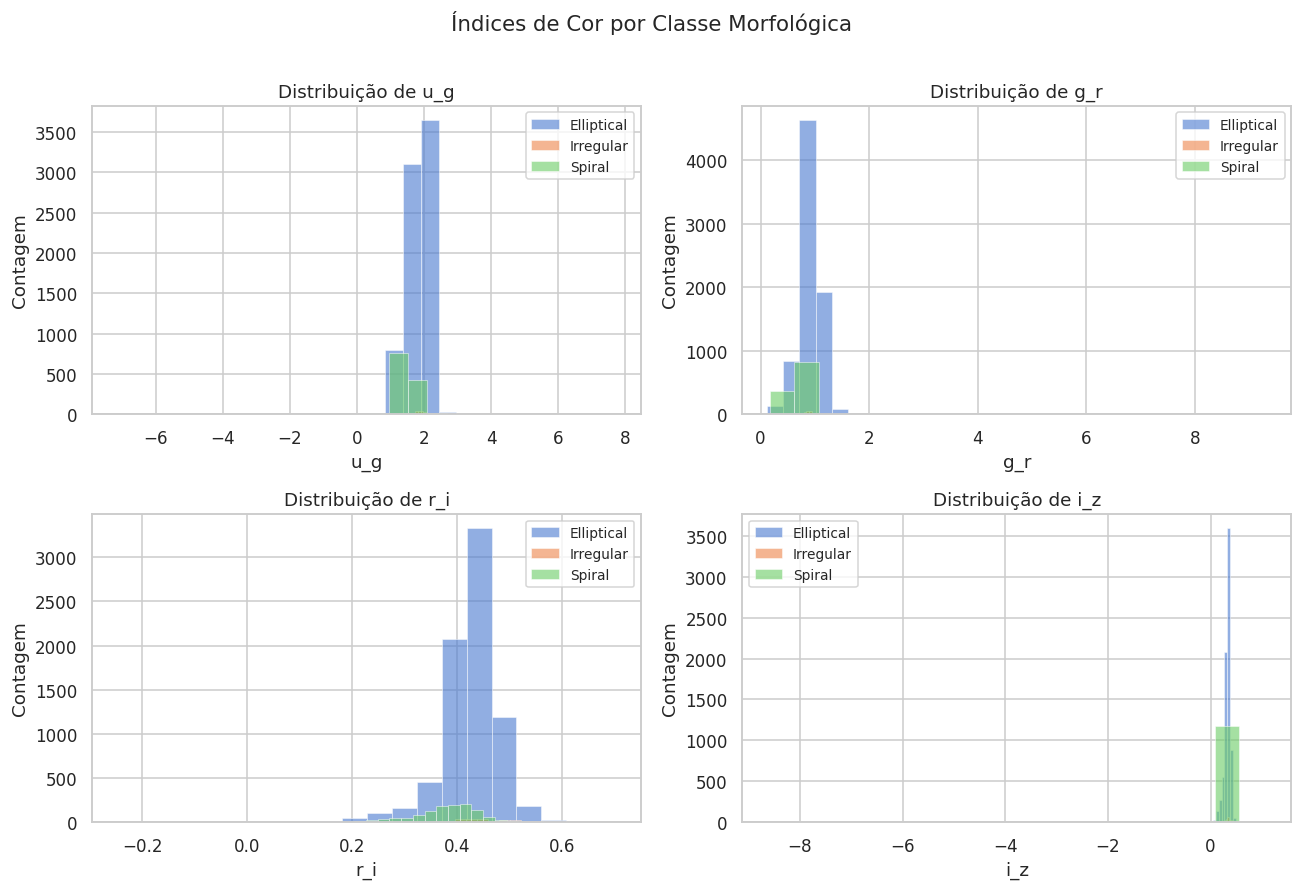

Figura salva: fig07_indices_cor_distribuicao.png


In [11]:
# Histogramas dos índices de cor por classe morfológica
color_indices = ['u_g', 'g_r', 'r_i', 'i_z']
classes       = df_eng['morph_class'].unique()
palette       = sns.color_palette('muted', n_colors=len(classes))
class_colors  = dict(zip(sorted(classes), palette))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, color_indices):
    for cls in sorted(classes):
        subset = df_eng[df_eng['morph_class'] == cls][col].dropna()
        ax.hist(subset, bins=20, alpha=0.6,
                label=cls, color=class_colors[cls], edgecolor='white', linewidth=0.5)
    ax.set_title(f'Distribuição de {col}', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Contagem')
    ax.legend(fontsize=9)

fig.suptitle('Índices de Cor por Classe Morfológica', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig07_indices_cor_distribuicao.png'),
            bbox_inches='tight')
plt.show()
print('Figura salva: fig07_indices_cor_distribuicao.png')

/tmp/ipykernel_8311/509266771.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_8311/509266771.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_8311/509266771.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_8311/509266771.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_8311/509266771.py:6: FutureWarning: 

Passing `pa

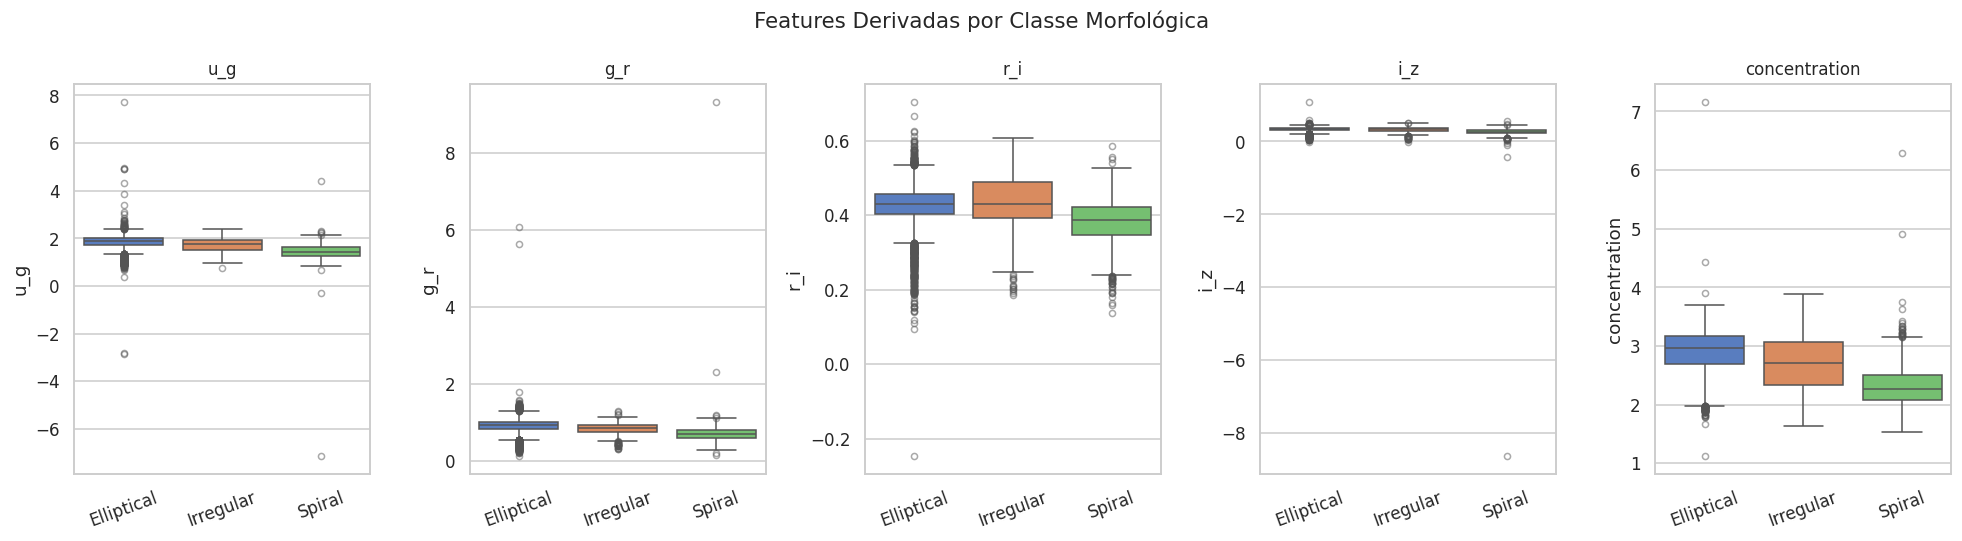

Figura salva: fig08_features_derivadas_boxplot.png


In [9]:
# Boxplots das 5 features derivadas por classe morfológica
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, col in zip(axes, derived_cols):
    order = sorted(df_eng['morph_class'].unique())
    sns.boxplot(
        data=df_eng, x='morph_class', y=col,
        order=order, palette='muted', ax=ax,
        flierprops=dict(marker='o', markersize=4, alpha=0.5)
    )
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

fig.suptitle('Features Derivadas por Classe Morfológica', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig08_features_derivadas_boxplot.png'),
            bbox_inches='tight')
plt.show()
print('Figura salva: fig08_features_derivadas_boxplot.png')

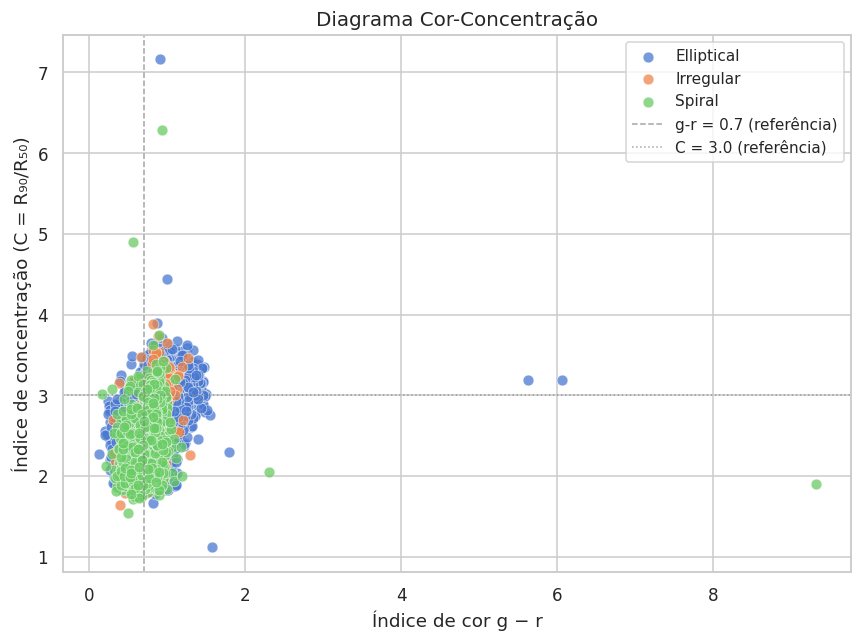

Figura salva: fig09_cor_concentracao.png


In [12]:
# Diagrama cor-cor: g-r vs concentration, colorido por classe
fig, ax = plt.subplots(figsize=(8, 6))

for cls in sorted(classes):
    subset = df_eng[df_eng['morph_class'] == cls]
    ax.scatter(subset['g_r'], subset['concentration'],
               label=cls, alpha=0.75, s=50,
               color=class_colors[cls], edgecolors='white', linewidths=0.4)

ax.axvline(x=0.7, color='gray', linestyle='--', linewidth=1, alpha=0.7,
           label='g-r = 0.7 (referência)')
ax.axhline(y=3.0, color='gray', linestyle=':',  linewidth=1, alpha=0.7,
           label='C = 3.0 (referência)')

ax.set_xlabel('Índice de cor g − r', fontsize=12)
ax.set_ylabel('Índice de concentração (C = R₉₀/R₅₀)', fontsize=12)
ax.set_title('Diagrama Cor-Concentração', fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig09_cor_concentracao.png'),
            bbox_inches='tight')
plt.show()
print('Figura salva: fig09_cor_concentracao.png')

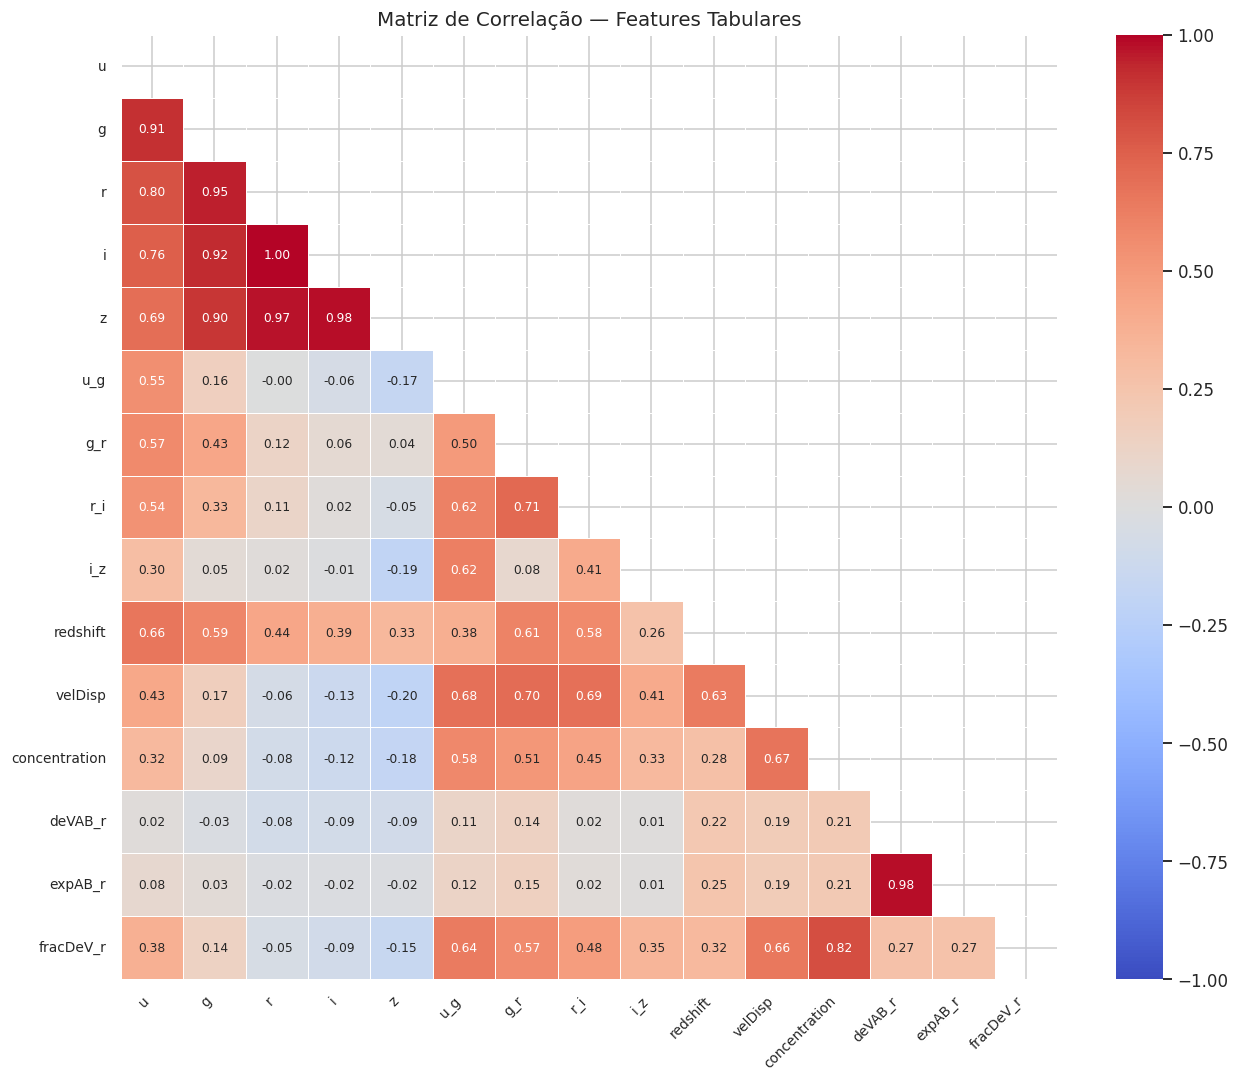

Figura salva: fig10_correlacao_features_tabulares.png


In [9]:
# Correlação entre todas as features tabulares (após engenharia)
# Usar apenas as linhas sem NaN para a matriz de correlação
df_corr = df_eng[TABULAR_FEATURES].dropna()

fig, ax = plt.subplots(figsize=(12, 10))
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1, linewidths=0.5,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Matriz de Correlação — Features Tabulares', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig10_correlacao_features_tabulares.png'),
            bbox_inches='tight')
plt.show()
print('Figura salva: fig10_correlacao_features_tabulares.png')


## 4. Pré-processamento Completo (Seleção + Limpeza + Escalonamento)

In [13]:
X_raw, y, _, objids = preprocess_tabular_data(df, scale=False)

print(f'\nShape de X_raw : {X_raw.shape}')
print(f'Shape de y     : {y.shape}')
print(f'Features usadas: {TABULAR_FEATURES}')
print('\nNota: escalonamento será aplicado no notebook 03, após o split train/val/test,')
print('      para que o StandardScaler seja ajustado apenas nos dados de treino.')

Registros originais : 9054
Removidos (NaN)     : 0
Registros finais    : 9054

Shape de X_raw : (9054, 15)
Shape de y     : (9054,)
Features usadas: ['u', 'g', 'r', 'i', 'z', 'u_g', 'g_r', 'r_i', 'i_z', 'redshift', 'velDisp', 'concentration', 'deVAB_r', 'expAB_r', 'fracDeV_r']

Nota: escalonamento será aplicado no notebook 03, após o split train/val/test,
      para que o StandardScaler seja ajustado apenas nos dados de treino.


In [14]:
# Estatísticas das features brutas (antes do escalonamento)
df_raw_check = pd.DataFrame(X_raw, columns=TABULAR_FEATURES)
print('Estatísticas das features brutas (pré-escalonamento):')
pd.DataFrame({
    'mean': df_raw_check.mean().round(4),
    'std':  df_raw_check.std().round(4),
    'min':  df_raw_check.min().round(3),
    'max':  df_raw_check.max().round(3),
})

Estatísticas das features brutas (pré-escalonamento):


,mean,std,min,max
u,18.985901,0.828700,15.821,24.643000
g,17.217400,0.700700,14.668,25.298000
r,16.333500,0.636000,14.012,17.686001
i,15.913800,0.632100,13.581,17.357000
z,15.596600,0.643900,13.230,24.118000
u_g,1.768500,0.344300,-7.157,7.731000
g_r,0.883900,0.226000,0.121,9.316000
r_i,0.419700,0.058200,-0.248,0.704000
i_z,0.317200,0.114200,-8.639,1.089000
redshift,0.087600,0.037300,0.020,0.241000



## 8. Pré-processamento de Imagens


---
## 5. Salvando Artefatos Tabulares

In [15]:
from preprocessing import save_preprocessed_tabular

save_preprocessed_tabular(
    X_scaled=X_raw,
    y=y,
    objids=objids,
    out_dir=PROCESSED_DIR,
    # scaler omitido: será ajustado no notebook 03 após o split
)

# Verificação de integridade
X_check, y_check, ids_check, _ = load_preprocessed_tabular(PROCESSED_DIR)
assert X_check.shape == X_raw.shape, f"Shape diverge! {X_check.shape} != {X_raw.shape}"
assert len(y_check) == len(y), "y_labels diverge após reload!"
print("\nVerificação de integridade: OK")


Artefatos salvos em '/home/luciano/Documentos/GalaxyNet/galaxy_classification/data/processed':
  X_tabular.npy  → shape (9054, 15), dtype float32
  y_labels.npy   → 9054 rótulos
  objids.npy     → 9054 IDs
  scaler.pkl     → não salvo (scaler será ajustado no notebook 03)
Carregado de '/home/luciano/Documentos/GalaxyNet/galaxy_classification/data/processed':
  X_tabular : (9054, 15)
  y_labels  : 9054 rótulos
  objids    : 9054 IDs

Verificação de integridade: OK


In [16]:
import glob
import cv2
from preprocessing import (
    IMAGE_TARGET_SIZE,
    IMAGE_STRETCH_FACTOR,
    preprocess_galaxy_image,
    preprocess_images_batch,
    save_preprocessed_images,
    load_preprocessed_images,
)

# _project_root e src_path já definidos na célula de imports (célula 1)
IMAGES_DIR = os.path.join(_project_root, 'data', 'images')
available  = glob.glob(os.path.join(IMAGES_DIR, '*.npy'))
raw_img      = None  # definido em célula seguinte se imagens existirem
sample_objid = None

print(f'Diretório de imagens     : {IMAGES_DIR}')
print(f'Arquivos .npy disponíveis: {len(available)}')

Diretório de imagens     : /home/luciano/Documentos/GalaxyNet/galaxy_classification/data/images
Arquivos .npy disponíveis: 9251


objid      : 1237651250973311061
Shape      : (64, 64, 3)  → (H, W, C), C = [g, r, i]
dtype      : float32
Valor min  : -0.0708
Valor max  : 24.6875
Valor médio: 0.2611


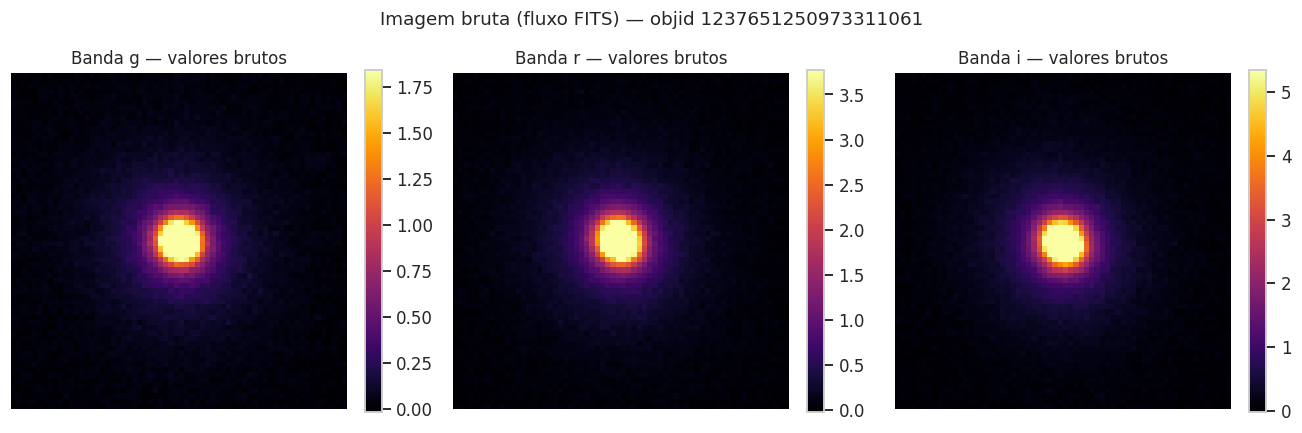

In [16]:
# Inspecionar uma imagem bruta (antes do pré-processamento)
if not available:
    print('AVISO: Nenhum arquivo .npy encontrado em', IMAGES_DIR)
    print('       Execute download_images.py para baixar as imagens antes de continuar.')
    raw_img      = None
    sample_objid = None
else:
    sample_path  = available[0]
    sample_objid = os.path.basename(sample_path).replace('.npy', '')
    raw_img      = np.load(sample_path)

    print(f'objid      : {sample_objid}')
    print(f'Shape      : {raw_img.shape}  → (H, W, C), C = [g, r, i]')
    print(f'dtype      : {raw_img.dtype}')
    print(f'Valor min  : {raw_img.min():.4f}')
    print(f'Valor max  : {raw_img.max():.4f}')
    print(f'Valor médio: {raw_img.mean():.4f}')

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    bands = ['g', 'r', 'i']
    for ax, ch, band in zip(axes, range(3), bands):
        data = raw_img[:, :, ch]
        vmin, vmax = np.percentile(data, [1, 99])
        im = ax.imshow(np.clip(data, vmin, vmax), cmap='inferno', origin='lower')
        ax.set_title(f'Banda {band} — valores brutos', fontsize=11)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(f'Imagem bruta (fluxo FITS) — objid {sample_objid}', fontsize=12)
    plt.tight_layout()
    plt.show()


In [17]:
if raw_img is None:
    print('Célula ignorada — sem imagens disponíveis.')
else:
    # Comparação: imagem bruta vs pré-processada (arcsinh + min-max)
    processed_img = preprocess_galaxy_image(
        raw_img,
        target_size=IMAGE_TARGET_SIZE,
        stretch_factor=IMAGE_STRETCH_FACTOR,
    )
    
    print(f'Shape processada : {processed_img.shape}')
    print(f'dtype            : {processed_img.dtype}')
    print(f'Valor min        : {processed_img.min():.4f}  (esperado ≥ 0.0)')
    print(f'Valor max        : {processed_img.max():.4f}  (esperado ≤ 1.0)')
    
    fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    for col, band in enumerate(bands):
        # Linha 0 — bruta
        raw_ch         = raw_img[:, :, col]
        vmin, vmax     = np.percentile(raw_ch, [1, 99])
        im0 = axes[0, col].imshow(np.clip(raw_ch, vmin, vmax),
                                   cmap='inferno', origin='lower')
        axes[0, col].set_title(f'Bruta — banda {band}', fontsize=11)
        axes[0, col].axis('off')
        plt.colorbar(im0, ax=axes[0, col], fraction=0.046).ax.tick_params(labelsize=7)
    
        # Linha 1 — pré-processada
        im1 = axes[1, col].imshow(processed_img[:, :, col],
                                   cmap='inferno', vmin=0, vmax=1, origin='lower')
        axes[1, col].set_title(f'Pré-processada — banda {band}', fontsize=11)
        axes[1, col].axis('off')
        plt.colorbar(im1, ax=axes[1, col], fraction=0.046).ax.tick_params(labelsize=7)
    
    fig.suptitle(f'Imagem bruta vs pré-processada — objid {sample_objid}', fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(REPORTS_DIR, 'fig13_raw_vs_processed.png'), bbox_inches='tight')
    plt.show()
    print('Figura salva: fig13_raw_vs_processed.png')


Célula ignorada — sem imagens disponíveis.


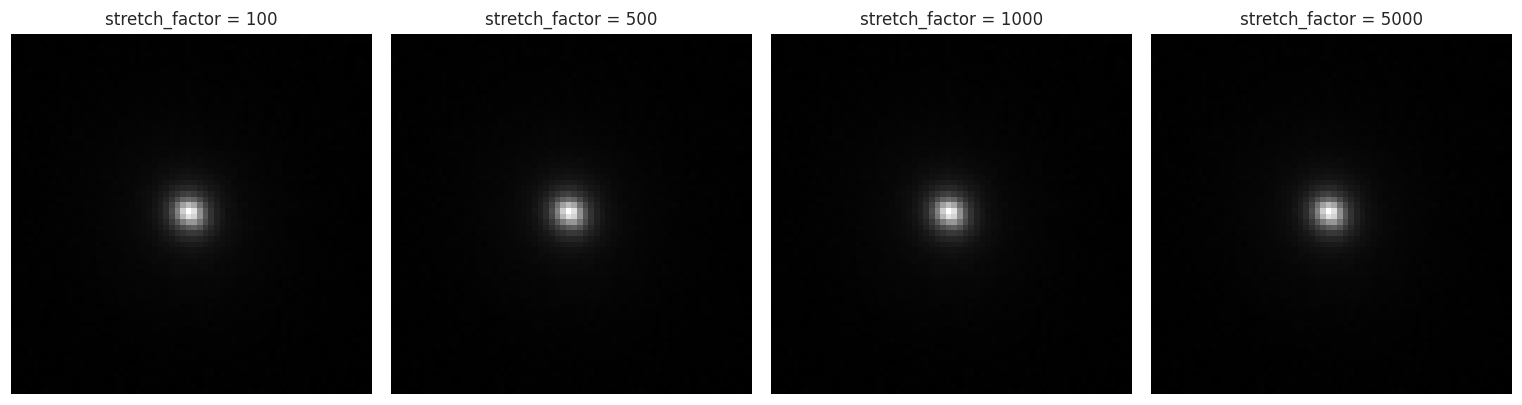

Figura salva: fig14_stretch_factor.png


In [18]:
if raw_img is None:
    print('Célula ignorada — sem imagens disponíveis.')
else:
    # Efeito do stretch_factor no contraste visual (banda r)
    stretch_values = [100, 500, 1000, 5000]
    channel        = raw_img[:, :, 1]  # banda r

    fig, axes = plt.subplots(1, len(stretch_values), figsize=(14, 4))
    for ax, sf in zip(axes, stretch_values):
        stretched = np.arcsinh(channel / sf)
        ch_min, ch_max = stretched.min(), stretched.max()
        if ch_max > ch_min:
            norm = (stretched - ch_min) / (ch_max - ch_min)
        else:
            norm = np.zeros_like(stretched)
        ax.imshow(norm, cmap='gray', origin='lower', vmin=0, vmax=1)
        ax.set_title(f'stretch_factor = {sf}', fontsize=11)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(REPORTS_DIR, 'fig14_stretch_factor.png'), bbox_inches='tight')
    plt.show()
    print('Figura salva: fig14_stretch_factor.png')


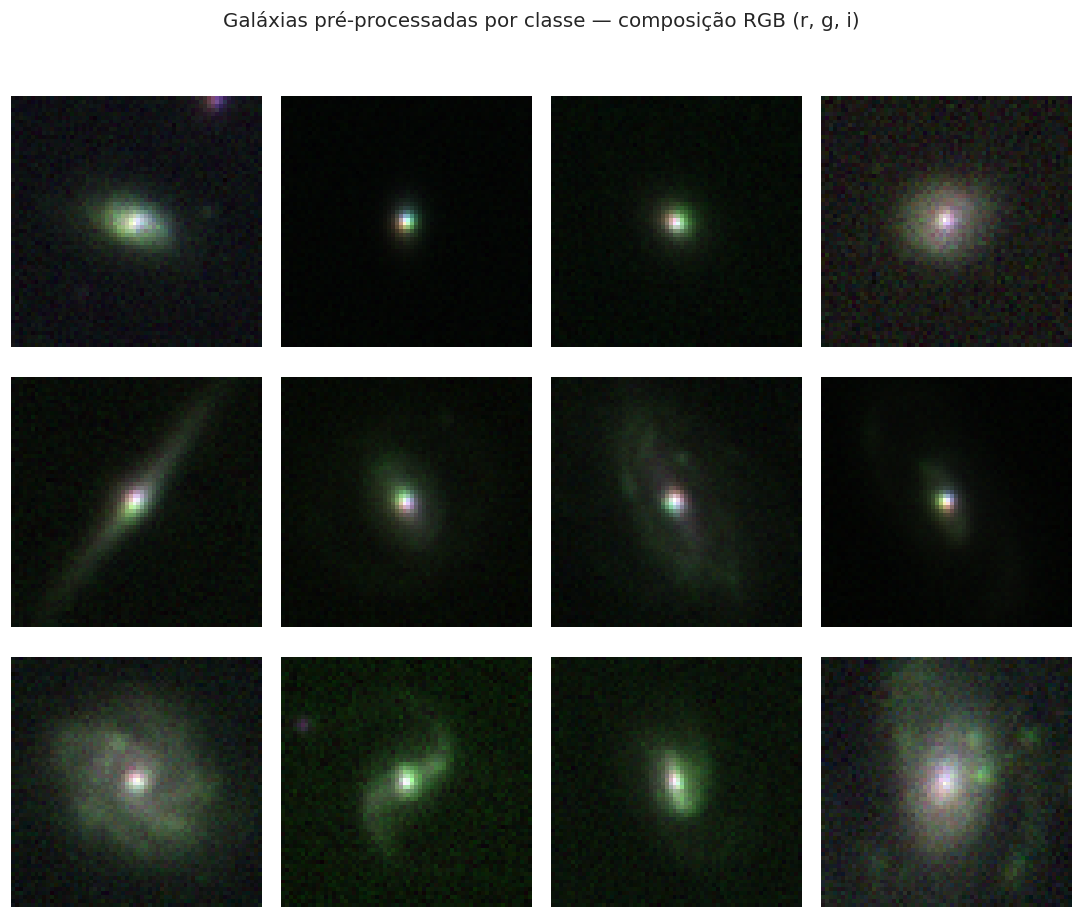

Figura salva: fig15_galaxy_grid_preprocessed.png


In [18]:
# Grid de galáxias pré-processadas por classe morfológica
# Composição RGB: canal r → R, g → G, i → B
catalog_df = df  # já filtrado neste notebook (outliers de precisão removidos)

samples_per_class = 4

# Compatível com pandas 1.x e 2.x — evita groupby().apply() que muda comportamento
sample_rows = pd.concat([
    group.sample(min(samples_per_class, len(group)), random_state=SEED)
    for _, group in catalog_df.groupby('morph_class')
]).reset_index(drop=True)

classes_present = sorted(sample_rows['morph_class'].unique())
n_rows = len(classes_present)
fig, axes = plt.subplots(n_rows, samples_per_class,
                         figsize=(samples_per_class * 2.5, n_rows * 2.8))
if n_rows == 1:
    axes = axes[np.newaxis, :]

for row_idx, cls in enumerate(classes_present):
    cls_rows = sample_rows[sample_rows['morph_class'] == cls].reset_index(drop=True)
    for col_idx in range(samples_per_class):
        ax = axes[row_idx, col_idx]
        if col_idx >= len(cls_rows):
            ax.axis('off')
            continue
        objid    = int(cls_rows.loc[col_idx, 'objid'])
        img_path = os.path.join(IMAGES_DIR, f'{objid}.npy')
        if not os.path.exists(img_path):
            ax.text(0.5, 0.5, 'sem\nimagem', ha='center', va='center',
                    transform=ax.transAxes, fontsize=8, color='gray')
            ax.axis('off')
            continue
        proc = preprocess_galaxy_image(np.load(img_path))
        # r→R, g→G, i→B
        rgb  = np.stack([proc[:, :, 1], proc[:, :, 0], proc[:, :, 2]], axis=-1)
        ax.imshow(rgb, origin='lower')
        ax.axis('off')
        if col_idx == 0:
            ax.set_ylabel(cls, fontsize=11, rotation=0, labelpad=60, va='center')

fig.suptitle('Galáxias pré-processadas por classe — composição RGB (r, g, i)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig15_galaxy_grid_preprocessed.png'),
            bbox_inches='tight')
plt.show()
print('Figura salva: fig15_galaxy_grid_preprocessed.png')

In [19]:
# Processamento em lote de todas as imagens disponíveis no catálogo
print(f'Galáxias no catálogo : {len(catalog_df)}')
print(f'Imagens disponíveis  : {len(available)}')
print()

X_images, img_objids = preprocess_images_batch(
    catalog_df=catalog_df,
    images_dir=IMAGES_DIR,
    target_size=IMAGE_TARGET_SIZE,
    stretch_factor=IMAGE_STRETCH_FACTOR,
)

if len(X_images) > 0:
    print(f'\nShape de X_images : {X_images.shape}  → (N, H, W, C)')
    print(f'dtype             : {X_images.dtype}')
    print(f'Valor min global  : {X_images.min():.4f}')
    print(f'Valor max global  : {X_images.max():.4f}')
    print(f'Cobertura         : {100*len(X_images)/len(catalog_df):.1f}% do catálogo')
    print(f'Tamanho em memória: {X_images.nbytes/1e6:.1f} MB')
else:
    print('Nenhuma imagem encontrada. Execute download_images.py antes de continuar.')

Galáxias no catálogo : 9054
Imagens disponíveis  : 9251

Imagens processadas      : 9054
Imagens não encontradas  : 0

Shape de X_images : (9054, 64, 64, 3)  → (N, H, W, C)
dtype             : float32
Valor min global  : 0.0000
Valor max global  : 1.0000
Cobertura         : 100.0% do catálogo
Tamanho em memória: 445.0 MB


In [ ]:
# Salvar artefatos de imagem em data/processed/
if len(X_images) > 0:
    save_preprocessed_images(
        X_images=X_images,
        img_objids=img_objids,
        out_dir=PROCESSED_DIR,
    )

    # Verificação de integridade
    X_check, ids_check = load_preprocessed_images(PROCESSED_DIR)
    assert X_check.shape == X_images.shape, 'Shape diverge após reload!'
    assert np.allclose(X_check, X_images, atol=1e-5), 'Valores divergem após reload!'
    print('\nVerificação de integridade: OK')
else:
    print('Nenhuma imagem para salvar — execute o download primeiro.')


Imagens salvas em '/home/luciano/Documentos/GalaxyNet/galaxy_classification/data/processed':
  X_images.npy   → shape (9054, 64, 64, 3), dtype float32
  img_objids.npy → 9054 IDs
  Tamanho em memória: 445.0 MB
Carregado de '/home/luciano/Documentos/GalaxyNet/galaxy_classification/data/processed':
  X_images   : (9054, 64, 64, 3)
  img_objids : 9054 IDs
